In [14]:
def warn(*args, **kwargs):
    pass
import warnings
warnings.warn = warn # To ignore some warnings from sklearn logistic regression
from sklearn.exceptions import ConvergenceWarning # To avoid logistic regression failing in case of perfect separation

import datetime
import numpy as np
from scipy.optimize import minimize # minimizing function for AIOLI
import matplotlib.pyplot as plt
import seaborn as sns
from dataclasses import dataclass, field
import pandas as pd
from sklearn.linear_model import LogisticRegression # for classic logistic regression
from typing import Literal
from sklearn.neighbors import KDTree # For Knn for SMOTE

options={"disp": False} # To not get verbose from minimize function

In [15]:
import ipywidgets

# Algorithms

## Helper functions for algorithms

First I define some functions that will be used later in all algorithms.

In [16]:
def sig(z):
    """ Sigmoid function that avoids overflow """
    if z < 0:
        return np.exp(z) / (1 + np.exp(z))
    else:
        return 1 / (1 + np.exp(-z))

In [17]:
# NOTE TO DO : put in general algorithm function that if radius == NA then this is not done.
def project_onto_l2_ball(x,radius):
    """ Euclidean projection onto L2 ball"""
    norm = np.linalg.norm(x)
    if norm <= radius:
        return x
    return x * radius/norm

In [18]:
def calculate_OTB(array, method: Literal["suffix_averaging", "uniform", "last_iterate"] | None = None, p = 0.5):
    """ Weighted average function
    ----
    Parameters:
        p: Proportion of last observations to average over. Ex p = 0.3 means average over last 30% of observations.
    Methods:
        Suffix averaging: Average over last p percentage of observations.
        Uniform: Average over all iterates equally
        Last iterate: Consider only the last iterate.
        """
    n = len(array)
    # Check p is a proportion
    if p is None:
        p = 0.5
    if not (0 <= p <= 1):
        raise ValueError("p must be between 0 and 1")

    match method:
        case "suffix_averaging":
            i = round((1-p)*n)
            result = np.mean(array[i:], axis=0)
        case "last_iterate":
            last_iterate = n - 1
            result = array[last_iterate]
        case _: # Uniform is default
            result = np.mean(array, axis=0)

    return result

In [19]:
def log_loss(betas,data_x,data_y):
    """ Works for a vector of betas and a whole dataset"""
    return np.sum(np.logaddexp(0,-data_y*np.inner(data_x,betas)))

In [20]:
def generate_x(n,d, correlated = False, means = None, sds = None, highly_correlated = False, seed = 40, standardized = False):
    rng = np.random.default_rng(seed) # Random number generator
    x = []

    if sds is None:
        sds = rng.uniform(0.1,4,d)
    if means is None:
        means = [rng.normal(1,sd,1).item() for sd in sds]
    # Put variances in covariance matrix
    cov = np.diag(sds**2)

    if not correlated:
        x = rng.multivariate_normal(means,cov, size = n)
    if correlated:
        # Create off diagonal, triangular matrix
        off_diag = np.triu(rng.uniform(0,2, size = (d,d)))
        cov = cov + off_diag + off_diag.T
        x = rng.multivariate_normal(means,cov, size = n)
        if highly_correlated and d == 3:
            x1 = generate_x(n,1)
            x2 = x1 + rng.normal(2,1)
            x3 = x1 + x2
            x = np.concatenate((x1,x2,x3), axis = 1)

    if standardized:
        standardized_x = (x - np.mean(x, axis=0) ) / np.std(x, axis=0)
        x = standardized_x
    return x


In [21]:
generate_x(100,3, means = [2,2,1])

array([[-1.05838493e+00, -8.77332504e-01,  3.90052528e+00],
       [ 6.08908784e+00, -5.72824547e-01, -4.81545620e-01],
       [ 2.56960483e+00,  2.40565069e+00, -1.62910890e+00],
       [ 3.18701442e-01, -6.23674335e-01,  2.45692170e+00],
       [ 2.97096445e+00,  1.41798832e+00, -4.03956440e+00],
       [ 2.13262565e+00,  5.89933190e+00,  2.61041759e+00],
       [ 2.48679265e+00,  2.12341080e+00,  3.20054951e+00],
       [ 8.58684794e-01,  1.10256718e+00, -9.25211932e-01],
       [ 1.44256089e+00,  3.26823283e-01,  6.74297254e+00],
       [ 4.12819887e+00, -1.16378677e+00,  1.91129900e+00],
       [ 1.20254604e+00,  4.87426698e+00, -7.79676859e+00],
       [ 3.85457295e+00,  2.92145328e+00, -1.61164151e+00],
       [ 1.16501473e-01,  1.01340474e+00,  3.60647985e+00],
       [ 4.03484360e+00, -5.01909630e+00,  7.06888536e+00],
       [ 7.92782410e+00,  1.24959139e+00,  5.75082591e+00],
       [-5.10398626e-01,  2.14374477e+00,  4.08879645e+00],
       [ 1.59039720e-01,  4.54634259e+00

In [22]:
def generate_y(n,x, betas, seed = 40, plot = False, method: Literal["sigmoid", "sinusoidal", "quadratic", "sig(1/x)", "only_x1_x2"] | None = None):
    y = np.zeros(n)
    prob_y1 = np.zeros(n)
    rng = np.random.default_rng(seed) # Random number generator

    match method:
        case "sinusoidal":
            prob_y1 = [(1/2)*np.sin(np.inner(x_t,betas))+1/2 for x_t in x]
            y = [rng.choice([1,-1], size = 1, p = [prob_y1_t, 1-prob_y1_t]).item() for prob_y1_t in prob_y1]

        case "quadratic":
            prob_y1 = [sig(np.inner((x_t**2),betas)) for x_t in x]
            y = [rng.choice([1,-1], size = 1, p = [prob_y1_t, 1-prob_y1_t]).item() for prob_y1_t in prob_y1]

        case "sig(1/x)":
            prob_y1 = [sig(np.inner((1/x_t),betas)) for x_t in x]
            y = [rng.choice([1,-1], size = 1, p = [prob_y1_t, 1-prob_y1_t]).item() for prob_y1_t in prob_y1]

        case "only_x1_x2":
            x1_x2 = x[:,0:2]
            prob_y1 = [sig(np.inner(x1_x2_t,betas[0:2])) for x1_x2_t in x1_x2]
            y = [rng.choice([1,-1], size = 1, p = [prob_y1_t, 1-prob_y1_t]).item() for prob_y1_t in prob_y1]

        case _: # Sigmoid function is default
            prob_y1 = [sig(np.inner(x_t,betas)) for x_t in x]
            y = [rng.choice([1,-1], size = 1, p = [prob_y1_t, 1-prob_y1_t]).item() for prob_y1_t in prob_y1]

    # Graphs
    if plot:
        for i in range(x.shape[1]):
            sns.scatterplot(x = x[:,i].flatten(), y = prob_y1)
            plt.title(f"P(Y=1) over x{i}")
            plt.show()

    return np.array(y)

In [23]:
a = generate_x(100,3, means = [2,2,1])
generate_y(100, x = a, betas = [2,1,0.1],method = "sinusoidal" )


array([-1, -1,  1,  1,  1, -1,  1,  1, -1,  1,  1, -1,  1,  1, -1,  1, -1,
       -1, -1,  1,  1,  1,  1,  1,  1,  1, -1,  1, -1, -1, -1,  1,  1,  1,
        1,  1,  1, -1, -1,  1,  1,  1, -1, -1,  1, -1,  1,  1,  1,  1,  1,
       -1, -1, -1,  1, -1,  1, -1, -1, -1, -1, -1,  1,  1,  1,  1, -1, -1,
        1,  1,  1, -1, -1,  1,  1, -1,  1, -1, -1,  1, -1, -1,  1,  1,  1,
       -1, -1,  1,  1, -1, -1,  1,  1, -1,  1,  1,  1, -1, -1, -1])

### Test functions

In [24]:
hola = generate_x(200,2, means = [0.5,1.2])

In [25]:
adios = generate_y(200,generate_x(200,2, means = [0.5,1.2]),[0.1,0.3], method = "sinusoidal", plot = False)
# adios2 = generate_y(200,generate_x(200,3, means = xs_balanced),bs_balanced, method = "sinusoidal", plot = True)
print(sum(adios == 1))
print(sum(adios == -1))

128
72


## Online Gradient Descent

In [26]:
def online_gd(data_y, data_x, B, OTB_method = None, OTB_average_proportion = None):
    """Online gradient descent
    Parameters
    ---------
    n : float
        Size of the dataset
    d : float
        Dimension of the context vector, i.e. number of independent variables
    data_y : ndarray
        Vector with outcome(y) values. Dimensions: n x 1
    data_x: ndarray
        Array with independent variables. Dimensions: n x d
    eta: float
        Learning rate.
    B: float
        Radius of the L2 ball constraint for the parameter vector beta
    OTB_method: string
        Averaging method, default none which implies the averaging function default which is uniform.
    OTB_average_proportion:
    """

    # Start time
    start_time = datetime.datetime.now()

    # Get dimensions
    n = data_x.shape[0]
    d = data_x.shape[1]

    # Initialize vectors
    betas = np.zeros((n,d)) # Parameter vector of all n rounds.

    loss = np.zeros(n)
    G = 1 # Max gradient
    eta = 1
    gradient = np.zeros(d)
    y_hat = np.zeros(n)

    for t in range(n):
        # Observe context vector for this round
        xt = data_x[t]

        # Update parameter (beta)
        if t == 0:
            beta_tilde = np.zeros(d)
        else:
            beta_tilde = betas[t-1] - eta*gradient

        # Euclidean projection of beta onto the L2 ball
        #betas[t] = project_onto_l2_ball(beta_tilde,B)
        betas[t] = beta_tilde

        # Issue prediction
        y_hat[t] = sig(np.inner(betas[t],xt))

        # Observe true y from the data
        yt = data_y[t]

        # Calculate gradient and sum of gradients
        gradient = -yt*xt*sig(-yt*np.inner(xt,betas[t]))
        # update maximum gradient
        G = np.max([G,np.linalg.norm(gradient)**2])

        # Suffer loss
        loss[t] = np.logaddexp(0,-yt*np.inner(xt,betas[t]))

        # Recalculate eta
        eta = 1 / np.sqrt((t+1) * G) # Here t+1 simply because python initializes t to 0


    # Store endtime
    end_time =  datetime.datetime.now()

    # Get Batch estimate
    betas_OTB = calculate_OTB(betas, OTB_method, OTB_average_proportion)

    # Get Batch estimate loss
    loss_OTB =  log_loss(betas_OTB,data_x, data_y)

    return{
        "runtime" : (end_time - start_time).total_seconds(),
        "Total_Loss" : loss_OTB,
        "Online_Loss" : sum(loss),
        "Batch_estimate": betas_OTB,
        "All_Betas": betas,
        "predictions": y_hat
    }


### Testing ODG

In [27]:
#ogd = online_gd(n = 40,d = 3,data_y = y,data_x = x,B = 40)

## AIOLI

In [28]:
class AIOLI:
    def __init__(self):
        self.first_sum  = []
        self.etas_gradients = []
        self.x0 = [] # Initializer for minimizing algorithm
        self.reg_lambda = 0
        self.train_size = 0
        self.d = 0
        self.n = 0

    # Define function to minimize for AIOLI
    @staticmethod # Because I dont use the self
    def parameter_function_AIOLI(b, xt, reg_lambda, first_sum, etas_gradients):
        l_hat = np.inner(b,first_sum) + b @ etas_gradients @ b #  @ to do matrix-vector multiplication
        # Use function np.logaddexp = log(exp(x1) + exp(x2)) to ensure numerical stability, not sure how it works
        result = l_hat + np.logaddexp(0,np.inner(b,xt)) + np.logaddexp(0,np.inner(-b,xt)) + reg_lambda*np.linalg.norm(b)**2
        return result

    def new_point_loss(self,X,Y, OTB_method):
        convergence_new = 0
        beta_hat = np.zeros((self.train_size,self.d))
        first_sum  = np.zeros(self.d)
        etas_gradients = np.zeros((self.d,self.d))
        for t in range(self.train_size):
            # Minimize using data up until t-1
            result = minimize(self.parameter_function_AIOLI, self.x0, method = "l-bfgs-b", args=(X, self.reg_lambda,first_sum, etas_gradients))
            beta_hat[t] = result.x
            convergence_new += result.success
            # Update minimization elements for next round
            first_sum += self.first_sum[t]
            etas_gradients += self.etas_gradients[t]

        # Get OTB
        big_beta = calculate_OTB(beta_hat, OTB_method)

        # Suffer loss
        loss_point = np.logaddexp(0,-Y*np.inner(X,big_beta))

        return loss_point

    def new_data_loss(self,new_data_x,new_data_y, OTB_method: Literal["suffix_averaging", "uniform", "last_iterate"] | None = None):
        start_time = datetime.datetime.now()
        new_losses = [ self.new_point_loss(X,Y, OTB_method) for (X,Y) in zip(new_data_x,new_data_y) ] # Zip pairs the rows of x and y
        end_time = datetime.datetime.now()
        return{
                "runtime" : (end_time - start_time).total_seconds(),
                "loss" : sum(new_losses)
            }


    def fit(self, data_y, data_x, B, X, OTB_method = None, OTB_average_proportion = None, minimize_method = "l-bfgs-b"):
        """AIOLI
        This is the function to run AIOLI.

        Parameters
        ---------
        data_y : ndarray
            Vector with outcome(y) values. Dimensions: n x 1
        data_x: ndarray
            Array with independent variables. Dimensions: n x d
        B: float
            Radius of the L2 ball constraint for the parameter vector beta
        X: float
            Radius of the L2 ball constraint for the feature vector x"""
        # Record start time
        start_time = datetime.datetime.now()

        # Get data dimensions
        self.n = data_x.shape[0]
        n = self.n
        self.d = data_x.shape[1]
        d = self.d
        self.x0 = np.zeros(d) # Initializer for minimizing algorithm
        self.train_size = n
        # Initialize vectors for storage
        betas = np.zeros((n, d))
        ys = np.zeros(n)
        y_hats = np.zeros(n)
        loss = np.zeros(n)
        etas = np.zeros(n)
        gradients = np.zeros((n, d))
        self.reg_lambda = 1 / (B**2)

        # Keep sums for loss functions
        self.first_sum  = np.zeros((n, d))
        self.etas_gradients = np.zeros((n,d,d))
        first_sum  = np.zeros(d)
        etas_gradients = np.zeros((d,d))

        # Track convergence
        convergence = 0
        minimizer_gradient = 0

        # Run Algorithm
        for t in range(n):
            # Get context vector
            xt = data_x[t]

            # Update beta parameter
            # noinspection PyTypeChecker # This is to avoid the underlining which
            if t == 0: # Initialize to 0 for first round
                beta_tilde = np.zeros(d)
            else:
                result = minimize(self.parameter_function_AIOLI,
                                  np.zeros(d),
                                  method = minimize_method,
                                  args=(xt, self.reg_lambda,first_sum, etas_gradients),
                                  options = {"maxiter":100000}
                                  )
                betas[t] = result.x
                convergence += result.success
                minimizer_gradient += np.linalg.norm(result.jac)

            # Project beta onto set
            #betas[t] = project_onto_l2_ball(beta_tilde,B)
            #betas[t] = self.x0

            # Generate prediction
            y_hats[t] = np.inner(xt,betas[t])

            # Observe true y from data
            ys[t] = data_y[t]

             # Compute gradient
            gradients[t] = -ys[t]*xt*sig(-ys[t]*np.inner(xt,betas[t]))

            # Estimate eta
            etas[t] = np.exp(ys[t]*y_hats[t])/(1+B*X)

            # Suffer loss
            loss[t] = np.logaddexp(0,-ys[t]*np.inner(xt,betas[t]))

            # Compute elements for AIOLI loss function

            fs = gradients[t]*(1 - etas[t]*np.inner(betas[t],gradients[t]))
            eg = (etas[t] / 2) * np.outer(gradients[t], gradients[t])
            self.first_sum[t] = fs
            self.etas_gradients[t] = eg
            first_sum += fs
            etas_gradients += eg
            # Here this is separated and a bit reiterative because else the way the vector is stored messes up with the function. I tried multiple ways and this seemed the best one.
        # for loop ends

        # Get Batch estimate
        betas_OTB = calculate_OTB(betas, OTB_method, OTB_average_proportion)

        # Get Batch estimate loss
        loss_OTB = log_loss(betas_OTB,data_x, data_y)

        end_time = datetime.datetime.now()

        return{
            "runtime" : (end_time - start_time).total_seconds(),
            "Total_Loss" : loss_OTB,
            "Online_Loss" : sum(loss),
            "Batch_estimate": betas_OTB,
            "All_Betas": betas,
            "convergence" : convergence,
            "minimizer_gradient" : minimizer_gradient
        }



### Testing AIOLI

In [29]:
x = generate_x(15,3)
betas = np.random.uniform(0.1,5,3)
y = generate_y(15,x,betas = betas)

x_train = x[:10]
y_train = y[:10]
x_test = x[10:]
y_test = y[10:]

### AIOLI convergence check

In [30]:
aioli_model = AIOLI()
aioli_results = aioli_model.fit(data_y = y_train, data_x = x_train, X = 10, B = 40, minimize_method = "l-bfgs-b")
aioli_results

{'runtime': 0.056993,
 'Total_Loss': np.float64(1.1631833978090504e-58),
 'Online_Loss': np.float64(4.561093417913836),
 'Batch_estimate': array([-13.95224048, 103.25988657,  19.45850794]),
 'All_Betas': array([[   0.        ,    0.        ,    0.        ],
        [ -95.06813142,   96.33396222,  -92.60649999],
        [ -91.12143109,  -58.40624996,   85.24399308],
        [-101.41202765,  123.71376841,  -93.19895565],
        [ -40.95060494,   97.27147672,   42.95042909],
        [ 107.52329664,  184.03404091,  111.81084991],
        [ -75.56305962,  128.72758825,  -76.71529228],
        [  71.46845906,  147.70133419,  116.75776991],
        [  72.307017  ,  106.22325388,   80.42699619],
        [  13.29407726,  206.99969109,   19.91578915]]),
 'convergence': 9,
 'minimizer_gradient': np.float64(0.0009575591290719751)}

In [31]:
minimization_methods = ["l-bfgs-b",'bfgs',"CG"]

for method in minimization_methods:
    aioli_model = AIOLI()
    aioli_results = aioli_model.fit(data_y = y_train, data_x = x_train, X = 10, B = 40, minimize_method = method)
    print(f"Method: {method}")
    print(f"convergence: {aioli_results["convergence"]}")
    print(f"minimizer_gradient: {aioli_results["minimizer_gradient"]}")
    print(f"Online loss: {aioli_results["Online_Loss"]}")


Method: l-bfgs-b
convergence: 9
minimizer_gradient: 0.0009575591290719751
Online loss: 4.561093417913836
Method: bfgs
convergence: 6
minimizer_gradient: 0.0001832979454594206
Online loss: 4.5611229344820154
Method: CG
convergence: 6
minimizer_gradient: 0.000584037519086084
Online loss: 4.561190623207425


In [32]:
aioli_model.new_data_loss(new_data_x = x_test, new_data_y = y_test, OTB_method = "uniform")

{'runtime': 0.157672, 'loss': np.float64(2.4326812630225545)}

## Ada Grad

In [33]:
def online_AdaGrad(data_y, data_x, B_vector, OTB_method = None, OTB_average_proportion = None):
    """Online Adaptive Gradient
    Parameters
    ---------
    n : float
        Size of the dataset
    d : float
        Dimension of the context vector, i.e. number of independent variables
    data_y : ndarray
        Vector with outcome(y) values. Dimensions: n x 1
    data_x: ndarray
        Array with independent variables. Dimensions: n x d
    eta: float
        Learning rate.
    B_vector: array
        Hyperparemeter, originally represents
    OTB_method: string
        Averaging method, default none which implies the averaging function default which is uniform.
    OTB_average_proportion:
    """

    # Start time
    start_time = datetime.datetime.now()

    # Get dimensions
    n = data_x.shape[0]
    d = data_x.shape[1]

    # Initialize vectors
    betas = np.zeros((n,d)) # Parameter vector of all n rounds.
    loss = np.zeros(n)
    sum_gradient_square = np.zeros(d)

    for t in range(n):
        # Receive x and y
        xt = data_x[t]
        yt = data_y[t]

        # Suffer loss
        loss[t] = np.logaddexp(0,-yt*np.inner(xt,betas[t]))

        # Calculate gradient and sum of gradients
        gradient = -yt*xt*sig(-yt*np.inner(xt,betas[t]))
        sum_gradient_square += gradient**2

        # Output betas
        if t == (n-1):
            pass
        else:
            for i in range(d):
                if gradient[i] != 0:
                    eta_ti = (np.sqrt(2)*B_vector[i])/(2*np.sqrt(sum_gradient_square[i]))
                    betas[t+1,i] = betas[t,i] - eta_ti*gradient[i]
                else:
                    betas[t+1,i] = betas[t,i]

    # Store endtime
    end_time = datetime.datetime.now()

    # Get Batch estimate
    betas_OTB = calculate_OTB(betas, OTB_method, OTB_average_proportion)

    # Get Batch estimate loss
    loss_OTB =  log_loss(betas_OTB,data_x, data_y)

    return{
        "runtime" : (end_time - start_time).total_seconds(),
        "Total_Loss" : loss_OTB,
        "Online_Loss" : sum(loss),
        "Batch_estimate": betas_OTB,
        "All_Betas": betas
    }


In [34]:
def projected_online_AdaGrad(data_y, data_x, B_vector, OTB_method = None, OTB_average_proportion = None):
    """Online Adaptive Gradient
    Parameters
    ---------
    n : float
        Size of the dataset
    d : float
        Dimension of the context vector, i.e. number of independent variables
    data_y : ndarray
        Vector with outcome(y) values. Dimensions: n x 1
    data_x: ndarray
        Array with independent variables. Dimensions: n x d
    eta: float
        Learning rate.
    B_vector: array
        Hyperparemeter, originally represents
    OTB_method: string
        Averaging method, default none which implies the averaging function default which is uniform.
    OTB_average_proportion:
    """

    # Start time
    start_time = datetime.datetime.now()

    # Get dimensions
    n = data_x.shape[0]
    d = data_x.shape[1]

    # Initialize vectors
    betas = np.zeros((n,d)) # Parameter vector of all n rounds.
    loss = np.zeros(n)
    sum_gradient_square = np.zeros(d)
    b_min = - B_vector / 2
    b_max = B_vector / 2

    for t in range(n):
        # Receive x and y
        xt = data_x[t]
        yt = data_y[t]

        # Suffer loss
        loss[t] = np.logaddexp(0,-yt*np.inner(xt,betas[t]))

        # Calculate gradient and sum of gradients
        gradient = -yt*xt*sig(-yt*np.inner(xt,betas[t]))
        sum_gradient_square += gradient**2

        # Output betas
        if t == (n-1):
            pass
        else:
            for i in range(d):
                if gradient[i] != 0:
                    eta_ti = (np.sqrt(2)*B_vector[i])/(2*np.sqrt(sum_gradient_square[i]))
                    betas[t+1,i] = max(min(betas[t,i] - eta_ti*gradient[i],b_min[i]),b_max[i])
                else:
                    betas[t+1,i] = betas[t,i]

    # Store endtime
    end_time = datetime.datetime.now()

    # Get Batch estimate
    betas_OTB = calculate_OTB(betas, OTB_method, OTB_average_proportion)

    # Get Batch estimate loss
    loss_OTB =  log_loss(betas_OTB,data_x, data_y)

    return{
        "runtime" : (end_time - start_time).total_seconds(),
        "Total_Loss" : loss_OTB,
        "Online_Loss" : sum(loss),
        "Batch_estimate": betas_OTB,
        "All_Betas": betas
    }


In [35]:
min([2,3,5])

2

In [36]:
x = generate_x(150,3, means= [2,2,1])
betas = [2,20,-4.2]
y = generate_y(150,x,betas = betas)

x_train = x[:100]
y_train = y[:100]
x_test = x[100:]
y_test = y[100:]

standardized_x_train = (x_train - np.mean(x_train, axis=0) ) / np.std(x_train, axis=0)
#x_train = standardized_x_train

In [37]:
ag_trial = online_AdaGrad(y_train, x_train, np.repeat(40/13,3))
ag_trial
print(log_loss(ag_trial["Batch_estimate"],x_test,y_test))
ag_u = calculate_OTB(ag_trial["All_Betas"], "uniform")
ag_s  = calculate_OTB(ag_trial["All_Betas"], "suffix_averaging")
ag_li  = calculate_OTB(ag_trial["All_Betas"], "last_iterate")
print(f"{log_loss(ag_u,x_test,y_test)}, {log_loss(ag_s,x_test,y_test)},  {log_loss(ag_li,x_test,y_test)}" )


3.514437251663476
3.514437251663476, 4.573952634660621,  4.786605559934853


In [38]:
og_trial = online_gd(y_train, x_train, 40)
og_trial
log_loss(og_trial["Batch_estimate"],x_test,y_test)

np.float64(7.698978531809346)

## Logistic Regression

In [39]:
def classic_logistic_regression(data_x, data_y):
    # Using safe implementation where if data is perfectly separable, then it's just fit minimizing the logistic loss.
    start_time = datetime.datetime.now()

    logreg = LogisticRegression(penalty=None, fit_intercept=False, max_iter=10000)

    try:
        logreg.fit(data_x, data_y)
        betas = logreg.coef_.flatten()

    except ValueError:
        # Single class case: fit manually using scipy minimize on the logistic loss
        def logistic_loss(b):
            scores = data_x @ b
            return np.sum(np.logaddexp(0, -data_y * scores))

        result = minimize(logistic_loss, x0=np.zeros(data_x.shape[1]),
                         options={"maxiter": 10000})
        betas = result.x
        print("Logistic regression was fit manually")

    loss = log_loss(betas, data_x, data_y)
    end_time = datetime.datetime.now()
    return {
        "runtime": (end_time - start_time).total_seconds(),
        "Total_Loss": loss,
        "Batch_estimate": betas
    }

In [40]:
# def classic_logistic_regression(data_x,data_y): #Using scikit learn
#     start_time = datetime.datetime.now()
#     # Initialize the model
#     logreg = LogisticRegression(penalty=None, fit_intercept=False)
#
#     # fit the model with data
#     logreg.fit(data_x,data_y)
#     betas = logreg.coef_.flatten() # flatten is To ensure it's a one dimensional array of d elements
#
#     loss = log_loss(betas, data_x, data_y)
#     end_time = datetime.datetime.now()
#     return{
#         "runtime" : (end_time - start_time).total_seconds(),
#         "Total_Loss" : loss,
#         "Batch_estimate": betas
#     }

## Ridge Logistic Regression

In [41]:
def ridge_logistic_regression(data_x, data_y, reg_lambda=1.0):
    start_time = datetime.datetime.now()

    logreg = LogisticRegression(penalty='l2', C=1/reg_lambda, fit_intercept=False, max_iter=10000, random_state=1)

    try:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", ConvergenceWarning)
            logreg.fit(data_x, data_y)
        betas = logreg.coef_.flatten()

    except ValueError:
        def ridge_logistic_loss(b):
            scores = data_x @ b
            return np.sum(np.logaddexp(0, -data_y * scores)) + reg_lambda * np.linalg.norm(b)**2

        result = minimize(ridge_logistic_loss, x0=np.zeros(data_x.shape[1]),
                         options={"maxiter": 10000})
        betas = result.x
        print("Ridge LG was fit manually")

    loss = log_loss(betas, data_x, data_y)
    end_time = datetime.datetime.now()
    return {
        "runtime": (end_time - start_time).total_seconds(),
        "Total_Loss": loss,
        "Batch_estimate": betas
    }

In [42]:
# def ridge_logistic_regression(data_x,data_y): #Using scikit learn
#     start_time = datetime.datetime.now()
#     # Initialize the model
#     logreg = LogisticRegression(penalty="l2", random_state=1, fit_intercept=False)
#
#     # fit the model with data
#     logreg.fit(data_x,data_y)
#     betas = logreg.coef_.flatten() # flatten is To ensure it's a one dimensional array of d elements
#
#     loss = log_loss(betas, data_x, data_y)
#     end_time = datetime.datetime.now()
#     return{
#         "runtime" : (end_time - start_time).total_seconds(),
#         "Total_Loss" : loss,
#         "Batch_estimate": betas
#     }

## Lasso Logistic Regression

In [43]:
def lasso_logistic_regression(data_x, data_y, reg_lambda=1.0):
    start_time = datetime.datetime.now()

    logreg = LogisticRegression(penalty='l1', C=1/reg_lambda, fit_intercept=False, max_iter=10000, random_state=1)

    try:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", ConvergenceWarning)
            logreg.fit(data_x, data_y)
        betas = logreg.coef_.flatten()

    except ValueError:
        def lasso_logistic_loss(b):
            scores = data_x @ b
            return np.sum(np.logaddexp(0, -data_y * scores)) + reg_lambda * np.abs(np.linalg.norm(b, ord = 1))

        result = minimize(lasso_logistic_loss, x0=np.zeros(data_x.shape[1]),
                         options={"maxiter": 10000})
        betas = result.x
        print("Lasso LG was fit manually")

    loss = log_loss(betas, data_x, data_y)
    end_time = datetime.datetime.now()
    return {
        "runtime": (end_time - start_time).total_seconds(),
        "Total_Loss": loss,
        "Batch_estimate": betas
    }

## Sample Minmax Predictor (SMP)

In [44]:
class sample_minmax_predictor():
    def __init__(self,data_x, data_y):
        self.data_x = data_x
        self.data_y = data_y
        self.d = 0

    def parameter_function(self,b,x,y = 1):
        # Use y = 1 to get the conditional density for P(Y=1)
        #result = log_loss(b,self.data_x,self.data_y) + log_loss(b,x,y)
        result = np.sum(np.logaddexp(0,-self.data_y*np.inner(self.data_x,b))) + np.logaddexp(0,-y*np.inner(x,b))
        return result

    def get_point_loss(self, new_x,new_y):
        self.d = self.data_x.shape[1]
        x0 = np.zeros(self.d)
        # Get parameter estimate
        beta_hat_y1 = minimize(self.parameter_function, x0=x0, method = "l-bfgs-b", args=(new_x,  1)).x
        beta_hat_y_1 = minimize(self.parameter_function, x0=x0, method = "l-bfgs-b", args=( new_x, -1)).x

        # Get conditional density for P(Y=1)
        f_tilde = sig(1*np.inner(beta_hat_y1,new_x)) / ( sig(np.inner(beta_hat_y1,new_x)*1) + sig(np.inner(beta_hat_y_1,new_x)*(-1)) )

        # Get loss (binary cross entropy)
        loss_point = (new_y == 1)*(-np.log(f_tilde)) + (new_y == -1)*(-np.log(1 - f_tilde))

        return loss_point

    def get_new_loss(self, new_data_x, new_data_y):
        start_time = datetime.datetime.now()
        new_losses = [self.get_point_loss(X,Y) for (X,Y) in zip(new_data_x,new_data_y)]
        end_time = datetime.datetime.now()
        return{
            "runtime" : (end_time - start_time).total_seconds(),
            "loss" : sum(new_losses),
            "loss_t" : new_losses
        }


### Testing SMP

In [45]:
smp = sample_minmax_predictor(x_train, y_train)
smp.get_new_loss(x_test, y_test)

{'runtime': 0.410651,
 'loss': np.float64(2.810883048173729),
 'loss_t': [np.float64(0.6931471208922974),
  np.float64(0.0022846379747213353),
  np.float64(0.11662633519489893),
  np.float64(0.001045841289610739),
  np.float64(0.041570490976528776),
  np.float64(0.00020387896822988893),
  np.float64(4.1259992138197904e-05),
  np.float64(8.462996148563366e-05),
  np.float64(0.03277163796267364),
  np.float64(0.00048577467325178414),
  np.float64(8.214199216579987e-05),
  np.float64(0.6931476675129636),
  np.float64(0.0004642952322180245),
  np.float64(0.0021521669707807757),
  np.float64(0.001001913883431694),
  np.float64(0.0028130426969296064),
  np.float64(0.16523789281204027),
  np.float64(0.035780104886023775),
  np.float64(0.0017881127520274786),
  np.float64(0.0008290745954057883),
  np.float64(0.012483283563769149),
  np.float64(0.0017237146009882849),
  np.float64(4.954655019252726e-06),
  np.float64(6.262429643623587e-06),
  np.float64(0.00013364094113501449),
  np.float64(0.0

## Ridge-regularized SMP

In [46]:
class ridge_sample_minmax_predictor():
    def __init__(self,data_x, data_y, reg_lambda = 0.2):
        self.data_x = data_x
        self.data_y = data_y
        self.d = 0
        self.n = 0
        self.reg_lambda = reg_lambda

    def parameter_function(self,b,x,y = 1):
        # Use y = 1 to get the conditional density for P(Y=1)
        #result = log_loss(b,self.data_x,self.data_y) + log_loss(b,x,y)
        result = (np.sum(np.logaddexp(0,-self.data_y*np.inner(self.data_x,b))) + np.logaddexp(0,-y*np.inner(x,b))) / (self.n + 1) + (self.reg_lambda/2) * np.linalg.norm(b)**2
        return result

    def get_point_loss(self, new_x,new_y):
        self.d = self.data_x.shape[1]
        x0 = np.zeros(self.d)
        # Get parameter estimate
        beta_hat_y1 = minimize(self.parameter_function, x0=x0, method = "l-bfgs-b", args=(new_x,  1)).x
        beta_hat_y_1 = minimize(self.parameter_function, x0=x0, method = "l-bfgs-b", args=( new_x, -1)).x

        # Get conditional density for P(Y=1)
        f_tilde = (sig(1*np.inner(beta_hat_y1,new_x)) * np.exp(1/2 * -self.reg_lambda * np.linalg.norm(beta_hat_y1)**2)) / ( ( sig(np.inner(beta_hat_y1,new_x)*1) * np.exp(1/2 * -self.reg_lambda * np.linalg.norm(beta_hat_y1)**2) )  + ( sig(np.inner(beta_hat_y_1,new_x)*(-1)) * np.exp(1/2 * -self.reg_lambda * np.linalg.norm(beta_hat_y_1)**2) ) )

        # Get loss (binary cross entropy)
        loss_point = (new_y == 1)*(-np.log(f_tilde)) + (new_y == -1)*(-np.log(1 - f_tilde))

        return loss_point

    def get_new_loss(self, new_data_x, new_data_y):
        start_time = datetime.datetime.now()
        self.n = self.data_x.shape[0]
        new_losses = [self.get_point_loss(X,Y) for (X,Y) in zip(new_data_x,new_data_y)]
        end_time = datetime.datetime.now()
        return{
            "runtime" : (end_time - start_time).total_seconds(),
            "loss" : sum(new_losses),
            "loss_t" : new_losses
        }


## SMOTE

In [66]:
class SMOTE():
    def __init__(self,data_x, data_y ,seed = 40, k = 1, S = 100):
        """ This class performs SMOTE on a dataset. The apply_smote method returns the new data with synthetic samples """
        self.seed = seed
        self.rng = np.random.default_rng(self.seed)
        self.d = 0
        self.k = k
        self.Xmin = []
        self.new_data_y = []
        self.synthetic = [] # array to store synthetic samples
        self.new_i = 0 # variable to keep indices of new synthetic samples. Initialize to 0
        self.data_x = data_x
        self.data_y = data_y
        self.M = 0
        self.S = S

    def get_min_class_x(self):
        # Get proportion of y = 1
        prop_y1 = np.sum(self.data_y == 1) / len(self.data_y)
        # Get the value of y that is minority
        y_minority = 1 if prop_y1 < 0.5 else -1
        self.M = np.sum(self.data_y == y_minority)
        # Get only x values for which the outcome is part of the minority
        self.Xmin = self.data_x[self.data_y == y_minority]
        n_new_samples = int((self.S/100)*self.M)
        new_minority_ys = np.full(n_new_samples,y_minority)
        self.new_data_y = np.append(self.data_y,new_minority_ys)
        return True if prop_y1 == 0.5 else False

    def populate(self, s_j, i, nn_indices):
        while s_j != 0:
            # Chose one of the k nearest neighbours of i
            ss = self.rng.integers(0,self.k)
            # Now for every attribute
            for j in range(self.d):
                diff = self.Xmin[nn_indices[ss]][j] - self.Xmin[i][j]
                gap = self.rng.uniform(0,1)
                self.synthetic[self.new_i][j] = self.Xmin[i][j] + gap*diff
            # end for
            self.new_i += 1
            s_j -= 1

    def apply_smote(self):
        """Synthetic Minority Oversampling Technique (SMOTE)
        Parameters
        ---------
        Xmin : array
            Array of minority class samples
        M: int
            Number of minority class samples
        S: int
            Percentual amount of SMOTE
        """

        # Get the Xmin (x values with outcome from minority class)
        no_minority = self.get_min_class_x()

        if no_minority:
            print("Dataset is balanced")
            return {
                "new_data_x": self.data_x,
                "new_data_y": self.data_y
            }

        # If S is less than 100%, randomize the minority class samples as only a random percent of them will be SMOTEd
        if self.S < 100:
            self.M = (self.S/100)*self.M
            self.S = 100
        # Get number of synthetic samples
        s = int(self.S/100)
        # Get number of attributes
        self.d = self.Xmin.shape[1]
        # Assign correct dimensions to synthetic samples array
        self.synthetic = np.zeros((s*self.M,self.d))

        # Make k nearest neighbors tree
        tree = KDTree(self.Xmin)

        # Get synthetic samples for each datapoint
        for i in range(self.M):
            nn_indices = tree.query(self.Xmin[i:i+1], k = self.k)[1][0]  # First index [1] is to get only the item with the indices, that gives a dataframe of 1 row. Second index [0] is to get that row and simply get an array of the indices
            self.populate(s,i,nn_indices)
        new_data_x = np.concatenate((self.data_x, self.synthetic))
        return new_data_x,self.new_data_y



In [48]:
sm = SMOTE(data_x = hola, data_y = adios,S = 100)
smote_result_x, smote_result_y = sm.apply_smote()

In [49]:
smote_result_x.shape

(272, 2)

In [50]:
len(smote_result_y)

272

In [51]:
classic_logistic_regression(data_x=smote_result_x, data_y=smote_result_y)

{'runtime': 0.009896,
 'Total_Loss': np.float64(137.3135161638324),
 'Batch_estimate': array([0.24810667, 0.46986678])}

# Functions for simulations

## Data class for specifying simulation configuration

In [52]:
default_n = 200
default_runs = 5
@dataclass
class SimulationConfig:
    # Default is well specified
    runs: int = default_runs
    n: int = default_n
    d: int = 3
    data_seed: int = 40
    betas: list = field(default_factory=lambda: [2,0.1,-4.2]) # This is to create a new list every time.
    x_means: list = field(default_factory=lambda: [2,2,1])
    # These values of betas and x_means guarantee a P(Y=1) = 0.5, hence balanced classes.
    B: int = 40
    X: int = 10
    test_ratio: float = 0.3
    minimize_method: str = "l-bfgs-b"
    y_method: str = "sigmoid"

## Function to run simulations and get results

In [64]:
def run_simulation(cfg: SimulationConfig):
    runs = cfg.runs
    n = cfg.n
    d = cfg.d
    betas = cfg.betas
    x_means = cfg.x_means
    B = cfg.B
    X = cfg.X
    test_ratio = cfg.test_ratio
    minimize_method = cfg.minimize_method
    y_method = cfg.y_method
    data_seed = cfg.data_seed

    # results_all = []
    test_set_results = []
    y_counts = []
    start_time = datetime.datetime.now()
    for i in range(runs):

        test_size = round(n * test_ratio)
        train_size = n - test_size
        # Generate data
        x = generate_x(n, d, means = x_means, seed = data_seed + i)
        y = generate_y(n, x, betas, seed = data_seed + i, method = y_method)

        # Store y counts to evaluate balance level later
        y_counts.append({
            "count_1": int(np.sum(y == 1)),
            "count_minus1": int(np.sum(y == -1))
        })


        # Split train/test
        x_train, y_train, x_test, y_test = x[:train_size], y[:train_size], x[train_size:], y[train_size:]

        # Debugging
        if i == 2:
            print(x_train)

        # Generate data again if trainingset only has one class
        y1_count_train = int(np.sum(y_train == 1))
        while y1_count_train == n or y1_count_train ==0:
            # Generate data
            x = generate_x(n, d, means = x_means, seed = data_seed + i)
            y = generate_y(n, x, betas, seed = data_seed + i, method = y_method)

            # Store y counts to evaluate balance level later
            y_counts.append({
                "count_1": int(np.sum(y == 1)),
                "count_minus1": int(np.sum(y == -1))
            })
            # Split train/test
            x_train, y_train, x_test, y_test = x[:train_size], y[:train_size], x[train_size:], y[train_size:]

            y1_count_train = int(np.sum(y_train == 1))



        # Get SMOTE dataset for unbalanced cases
        sm = SMOTE(data_x = x_train, data_y = y_train, S = 100)
        smote_x, smote_y = sm.apply_smote()

        # Run algorithms
        ogd = online_gd(data_y=y_train, data_x=x_train, B=B)
        adagrad = online_AdaGrad(data_y=y_train, data_x=x_train, B_vector = np.repeat(B/13,d))
        aioli_model = AIOLI()
        ai = aioli_model.fit(data_y=y_train, data_x=x_train, X=X, B=B, minimize_method = minimize_method)
        classic_lg = classic_logistic_regression(data_x=x_train, data_y=y_train)
        ridge_lg = ridge_logistic_regression(data_x=x_train, data_y=y_train)
        lasso_lg = lasso_logistic_regression(data_x=x_train, data_y=y_train)
        smp = sample_minmax_predictor(x_train, y_train)
        ridge_smp = ridge_sample_minmax_predictor(x_train, y_train)
        classic_lg_smote = classic_logistic_regression(data_x=smote_x, data_y=smote_y)


        # OTB estimates
        # OGD
        OGD_OTB_uniform = calculate_OTB(ogd["All_Betas"], "uniform")
        OGD_OTB_Suffix  = calculate_OTB(ogd["All_Betas"], "suffix_averaging")
        OGD_OTB_lastit  = calculate_OTB(ogd["All_Betas"], "last_iterate")
        # AdaGrad
        adagrad_OTB_uniform = calculate_OTB(adagrad["All_Betas"], "uniform")
        adagrad_OTB_Suffix  = calculate_OTB(adagrad["All_Betas"], "suffix_averaging")
        adagrad_OTB_lastit  = calculate_OTB(adagrad["All_Betas"], "last_iterate")

        ############################## TEST RESULTS ##############################
        # OGD
        loss_OGD_uniform_test = log_loss(OGD_OTB_uniform, x_test, y_test)
        loss_OGD_Suffix_test  = log_loss(OGD_OTB_Suffix,  x_test, y_test)
        loss_OGD_lastit_test  = log_loss(OGD_OTB_lastit,  x_test, y_test)

        # Adagrad
        loss_adagrad_uniform_test = log_loss(adagrad_OTB_uniform, x_test, y_test)
        loss_adagrad_Suffix_test  = log_loss(adagrad_OTB_Suffix,  x_test, y_test)
        loss_adagrad_lastit_test  = log_loss(adagrad_OTB_lastit,  x_test, y_test)

        # AIOLI
        loss_AIOLI_uniform_test = aioli_model.new_data_loss(new_data_x=x_test, new_data_y=y_test, OTB_method="uniform")["loss"]
        loss_AIOLI_Suffix_test = aioli_model.new_data_loss(new_data_x=x_test, new_data_y=y_test, OTB_method="suffix_averaging")["loss"]
        loss_AIOLI_lastit_test = aioli_model.new_data_loss(new_data_x=x_test, new_data_y=y_test, OTB_method="last_iterate")["loss"]

        # Logistic Regression
        loss_LG_test = log_loss(classic_lg["Batch_estimate"], x_test, y_test)
        loss_LG_smote_test = log_loss(classic_lg_smote["Batch_estimate"], x_test, y_test)
        loss_LG_Ridge_test = log_loss(ridge_lg["Batch_estimate"],   x_test, y_test)
        loss_LG_Lasso_test = log_loss(lasso_lg["Batch_estimate"],   x_test, y_test)

        # SMP
        smp_result = smp.get_new_loss(x_test, y_test)
        ridge_smp_result = ridge_smp.get_new_loss(x_test, y_test)

        algorithms_test = {
            "Classical_LG":  {"loss": loss_LG_test},
            "Classical_LG_SMOTE":      {"loss": loss_LG_smote_test},
            "Ridge_LG":      {"loss": loss_LG_Ridge_test},
            "Lasso_LG":      {"loss": loss_LG_Lasso_test},
            "OGD_uniform": {"loss": loss_OGD_uniform_test},
            "OGD_Suffix":  {"loss": loss_OGD_Suffix_test},
            "OGD_Last_iterate": {"loss": loss_OGD_lastit_test},
            "AdaGrad_uniform": {"loss": loss_adagrad_uniform_test},
            "AdaGrad_Suffix":  {"loss": loss_adagrad_Suffix_test},
            "AdaGrad_Last_iterate": {"loss": loss_adagrad_lastit_test},
            "AIOLI_uniform": {"loss": loss_AIOLI_uniform_test},
            "AIOLI_Suffix":  {"loss": loss_AIOLI_Suffix_test},
            "AIOLI_lastit":  {"loss": loss_AIOLI_lastit_test},
            "SMP":      {"loss": smp_result["loss"]},
            "Ridge_SMP":      {"loss": ridge_smp_result["loss"]}
        }

        for name, metrics in algorithms_test.items():
             test_set_results.append({
                "run": i,
                "algorithm": name,
                **metrics
            })
        print(f"Run {i+1} finished")

    endtime = datetime.datetime.now()
    return {
        # "final_results": pd.DataFrame(results_all),
        "test_results": pd.DataFrame(test_set_results),
         "y_counts": pd.DataFrame(y_counts),
        "total_time": (endtime - start_time).total_seconds()
    }


## Function for printing results

In [54]:
def print_results(results):
    # summary_train = results["final_results"].groupby("algorithm")[["runtime", "loss (trainset)", "online_loss", "betas"]].mean()
    # summary_train["betas"] = summary_train["betas"].apply(lambda array: np.round(array, 3))
    summary_test = results["test_results"].groupby("algorithm")[["loss"]].mean()
    print(f"Total time: {str(datetime.timedelta(seconds=results["total_time"]))}")
    # display(summary_train)
    display(summary_test)

## Function for graphing loss and Y=1 counts over runs

In [55]:
def plot_results(results, n = default_n):
    test_results = results["test_results"]

    # Boxplots of y counts
    sns.boxplot(data=results["y_counts"][["count_1", "count_minus1"]])
    plt.title("Distribution of Y counts across runs")
    plt.ylim(0, n)
    plt.show()

    # Line plot of Loss over rounds
    sns.lineplot(x = test_results["run"], y = test_results["loss"], hue = test_results["algorithm"]).set_title("Loss over rounds")
    plt.show()


# Experiments

## Balanced

### X means and betas for balanced data $P(Y=1) = 0.5)$

In [56]:
# Balanced
bs_balanced = [2,0.1,-4.2]
xs_balanced = [2,2,1]
print(np.inner(bs_balanced,xs_balanced))
print(sig(np.inner(bs_balanced,xs_balanced)))
print((1/2)*np.sin(np.inner(xs_balanced,bs_balanced)) + 1/2)

0.0
0.5
0.5


In [57]:
#balanced quadratic
xs_balanced_quadratic = np.array([1.45,0.5,1])
print(sig(np.inner(bs_balanced,xs_balanced_quadratic**2)))


0.5074994375506204


In [58]:
# Balanced High dimensional (25 variables)
bs_hd_balanced = [2,0.8,-4.2,1.4,0.5,0.2,-1,-0.3,1.2,-0.1,0.6,0.9,-2.4,2.7,-1.4,0.5,-1,4.2,1.5,-0.2,0.4,1.2,3.6,-0.8,-1.7]

xs_hd_balanced = [-1.6, 2.1, 0.4, 4.3, 0.9, -8.9, 6.9, 3.1,0.4, -1.1, 1.9, 0.3, 2.4, 1.0, -6.3, 0.2,3.1, -2.9, 3.1, 4.6, -0.3, 6.9, 2.4, 1.9, 3.1]


print(len(bs_hd_balanced), len(xs_hd_balanced))
print(np.inner(bs_hd_balanced,xs_hd_balanced))
print(sig(np.inner(bs_hd_balanced,xs_hd_balanced)))
print((1/2)*np.sin(np.inner(xs_hd_balanced,bs_hd_balanced)) + 1/2)

25 25
-0.02000000000000135
0.49500016665999996
0.4900006666533328


### Experiments

In [316]:
well_specified = SimulationConfig(
    runs = 2,
    n = default_n,
    d = 3,
    betas= bs_balanced,
    x_means= xs_balanced
)

well_specified_result = run_simulation(well_specified)
print_results(well_specified_result)

Lasso LG was fit manually
Run 1 finished
Lasso LG was fit manually
Run 2 finished
Total time: 0:02:08.989387


,loss
algorithm,
AIOLI_Suffix,46.154230
AIOLI_lastit,88.594833
AIOLI_uniform,36.339392
AdaGrad_Last_iterate,7.751363
AdaGrad_Suffix,8.538352
AdaGrad_uniform,7.187209
Classical_LG,6.376971
Classical_LG_SMOTE,6.755772
Lasso_LG,6.335513


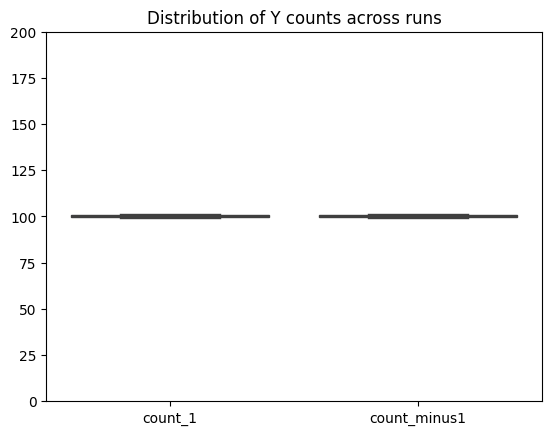

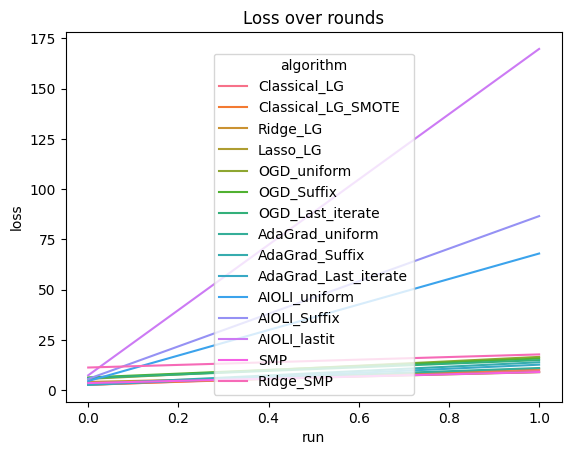

In [317]:
plot_results(well_specified_result, n = default_n)

In [318]:
high_dimensional = SimulationConfig(
    runs = 3,
    n = 20,
    d = 25,
    betas= bs_hd_balanced,
    x_means= xs_hd_balanced
)

high_dimensional_result = run_simulation(high_dimensional)
print_results(high_dimensional_result)

Lasso LG was fit manually
Run 1 finished
Lasso LG was fit manually
Run 2 finished
Lasso LG was fit manually
Run 3 finished
Total time: 0:00:26.383102


,loss
algorithm,
AIOLI_Suffix,4.107923
AIOLI_lastit,4.065697
AIOLI_uniform,4.128796
AdaGrad_Last_iterate,22.129632
AdaGrad_Suffix,37.260113
AdaGrad_uniform,83.265476
Classical_LG,8.846658
Classical_LG_SMOTE,8.853773
Lasso_LG,3.965445


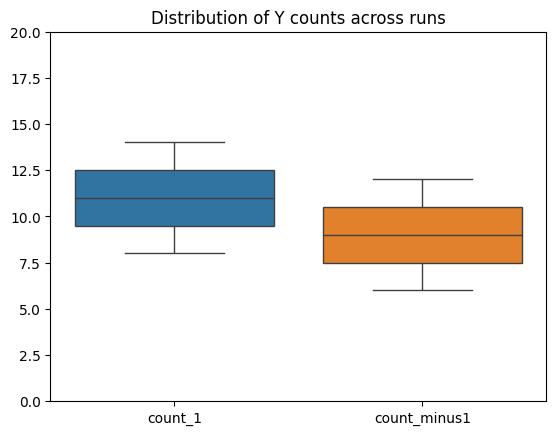

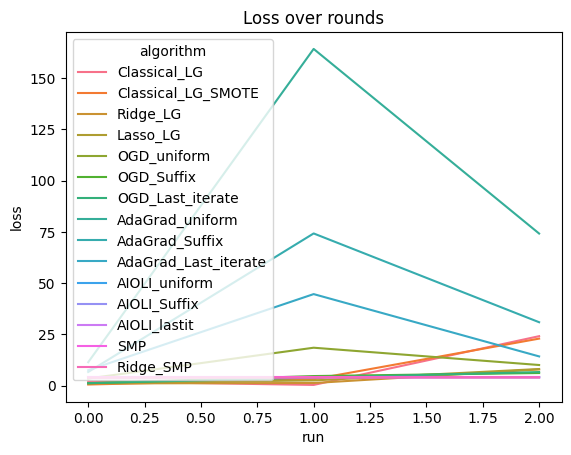

In [319]:
plot_results(high_dimensional_result, n = 20)

In [320]:
high_dimensionality = SimulationConfig(
    runs = 5,
    n = 50,
    d = 25,
    betas= bs_hd_balanced,
    x_means= xs_hd_balanced
)

high_dimensionality_result = run_simulation(high_dimensionality)
print_results(high_dimensionality_result)

Lasso LG was fit manually
Run 1 finished
Lasso LG was fit manually
Run 2 finished
Lasso LG was fit manually
Run 3 finished
Lasso LG was fit manually
Run 4 finished
Lasso LG was fit manually
Run 5 finished
Total time: 0:14:41.811232


,loss
algorithm,
AIOLI_Suffix,9.360287
AIOLI_lastit,8.581871
AIOLI_uniform,9.791483
AdaGrad_Last_iterate,130.520212
AdaGrad_Suffix,126.333590
AdaGrad_uniform,129.199859
Classical_LG,21.206989
Classical_LG_SMOTE,23.161479
Lasso_LG,8.044815


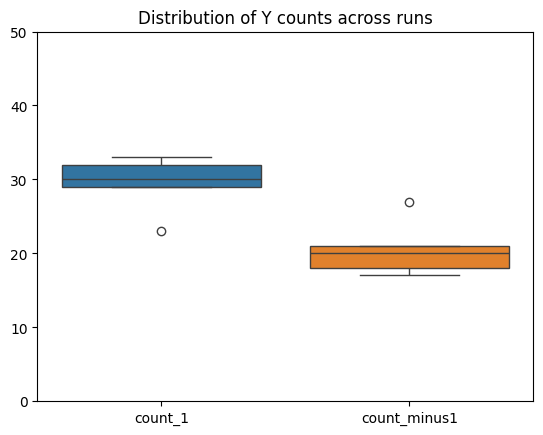

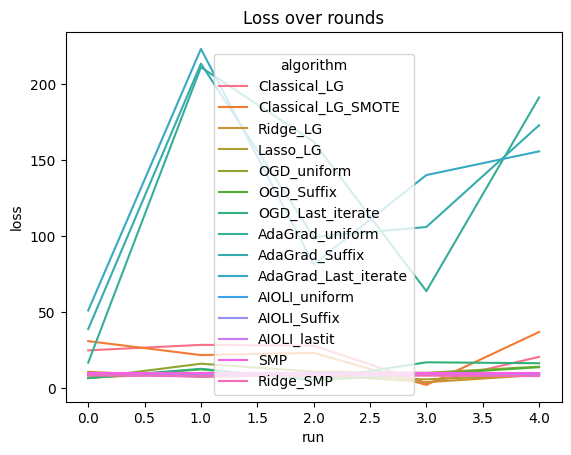

In [321]:
plot_results(high_dimensionality_result, n = 50)

In [67]:
sinusoidal = SimulationConfig(
    n = default_n,
    d = 3,
    betas= bs_balanced,
    x_means= xs_balanced,
    y_method = "sinusoidal"
)

sinusoidal_result = run_simulation(sinusoidal)
print_results(sinusoidal_result)

Lasso LG was fit manually
Run 1 finished
Lasso LG was fit manually
Run 2 finished
[[-4.08416391e+00 -3.59062141e-01  4.24356742e+00]
 [ 1.01382006e+00  1.96956259e+00  1.44086171e+00]
 [ 4.74233979e+00  3.40906803e+00 -1.94174919e+00]
 [ 5.51522121e+00  2.84695204e+00  1.22770897e+00]
 [ 3.14992299e+00  2.62863431e-01 -1.96329746e+00]
 [ 1.84430961e+00  1.66509855e+00  4.02936388e+00]
 [ 5.81240786e+00  1.72005039e+00 -1.34820725e+00]
 [ 9.01896669e-01  2.96434512e+00 -4.77102153e-01]
 [ 3.28707718e+00  2.78048649e+00  2.26024551e+00]
 [ 7.32623794e-01  1.07200780e+00  8.38554004e+00]
 [ 3.92088784e+00  4.04527546e+00 -1.80632120e+00]
 [-6.19967977e-01  5.06348463e-01  6.07048559e-01]
 [ 4.31778506e+00  2.98399235e+00  3.24358997e+00]
 [ 2.72397851e+00  2.21139104e+00 -1.29503145e+00]
 [ 4.71748841e+00  2.40507149e+00  1.75415460e+00]
 [ 2.21074050e+00  2.52377620e+00  3.34125507e+00]
 [-2.54403637e+00  1.42087534e+00  3.17701758e+00]
 [ 7.70505292e-03  1.50154517e+00 -6.22095097e-01]


AttributeError: 'str' object has no attribute 'shape'

In [ ]:
plot_results(sinusoidal_result)

In [ ]:
quadratic = SimulationConfig(
    n = default_n,
    d = 3,
    betas= bs_balanced,
    x_means= xs_balanced,
    y_method = "quadratic"
)

quadratic_result = run_simulation(quadratic)
print_results(quadratic_result)

In [ ]:
plot_results(quadratic_result)

## Unbalanced

### X means and betas for unbalanced data $P(Y=1)$ -> 1 or 0)


In [ ]:

# Unbalanced
bs_unbalanced = [1.5,0.1,-4.2]
xs_unbalanced = [2,2,1]
print(np.inner(bs_unbalanced,xs_unbalanced))
print(sig(np.inner(bs_unbalanced,xs_unbalanced)))
print((1/2)*np.sin(np.inner(xs_unbalanced,bs_unbalanced)) + 1/2)


In [ ]:
# Unbalanced High dimensional (25 variables)
bs_hd_unbalanced = [2,1.8,-4.2,1.4,0.5,0.2,-1,-0.3,1.2,-0.1,0.6,0.9,-2.4,2.7,-1.4,0.5,-1,4.2,1.5,-0.2,0.4,1.2,3.6,-0.8,-1.7]

xs_hd_unbalanced = [-1.6, 2.1, 0.4, 4.3, 0.9, -8.9, 6.9, 3.1,0.4, -1.1, 1.9, 0.3, 2.4, 1.0, -6.3, 0.2,3.1, -2.9, 3.1, 4.6, -0.3, 6.9, 2.4, 1.9, 3.1]


print(len(bs_hd_unbalanced), len(xs_hd_unbalanced))
print(np.inner(bs_hd_unbalanced,xs_hd_unbalanced))
print(sig(np.inner(bs_hd_unbalanced,xs_hd_unbalanced)))
print((1/2)*np.sin(np.inner(xs_hd_unbalanced,bs_hd_unbalanced)) + 1/2)

### Experiments

In [ ]:
well_specified_unbalanced = SimulationConfig(
    n = default_n,
    betas= bs_unbalanced,
    x_means= xs_unbalanced
)

well_specified_unbalanced_result = run_simulation(well_specified_unbalanced)
print_results(well_specified_unbalanced_result)

In [ ]:
plot_results(well_specified_unbalanced_result)

In [ ]:
high_dimensional_unbalanced = SimulationConfig(
    n = 20,
    d = 25,
    betas= bs_hd_unbalanced,
    x_means= xs_hd_unbalanced
)

high_dimensional_unbalanced_result = run_simulation(high_dimensional_unbalanced)
print_results(high_dimensional_unbalanced_result)


In [ ]:
plot_results(high_dimensional_unbalanced_result, n = 20)

In [ ]:
high_dimensionality_unbalanced = SimulationConfig(
    n = 50,
    d = 25,
    betas= bs_hd_unbalanced,
    x_means= xs_hd_unbalanced
)

high_dimensionality_unbalanced_result = run_simulation(high_dimensionality_unbalanced)
print_results(high_dimensionality_unbalanced_result)


In [ ]:
plot_results(high_dimensionality_unbalanced_result, n =50)

In [ ]:
sinusoidal_unbalanced = SimulationConfig(
    d = 3,
    betas= bs_unbalanced,
    x_means= xs_unbalanced,
    y_method = "sinusoidal"
)

sinusoidal_unbalanced_result = run_simulation(sinusoidal_unbalanced)
print_results(sinusoidal_unbalanced_result)

In [ ]:
plot_results(sinusoidal_unbalanced_result)

## Graphing different data generating functions

In [ ]:
# print(np.inner([1.5, 1.6, 0.7],[1.2, -0.9, -0.4]))
# bs_balanced = [2,0.1,-4.2]
# xs_balanced = [2,2,1]
# print(np.inner(bs_balanced,xs_balanced))

In [ ]:
# x_s = generate_x(100,d = 3, means = [0.5, 0.8, 0.4], correlated = False)
# betas_s = [1.2, 0.9, 0.4]
# y_s = generate_y(100,x_s,betas_s)
# # p_s = [sig(dot) for dot in np.inner(x_s,betas_s)]
# # print(np.std(p_s))
# # print(np.mean(p_s))
# pd.Series(y_s).value_counts()

In [ ]:
# y_s = generate_y(100,x_s,betas_s, enrique = False)

In [ ]:
# for i in range(x_s.shape[1]):
#     sns.scatterplot(x = range(len(x_s[:,i])), y = [sig(np.inner(x,betas_s)) for x in x_s] )
#     plt.title(f"P(Y=1) over x{i}")
#     plt.show()

In [ ]:
# i = 0
# [np.inner(x,betas_s) for x in x_s]


In [ ]:


# sig(np.inner(x_s[4],betas_s))
#y_s = generate_y(n = 100,x = x_s, betas = betas_s)

#sns.scatterplot(x = x_s[:,0].flatten(), y = y_s)

In [ ]:

# sns.lineplot(x = x_s[:,1].flatten(), y = y_s)

In [ ]:
# sns.lineplot(x = x_s[:,2].flatten(), y = y_s)

In [ ]:
# x_s[:,0].flatten()

In [ ]:

# Data
# y = np.array([1,1,1,1,1,1,1,1,1])
# X = np.array([
#     [1,3,2],
#     [2,3,6],
#     [3,1,4],
#     [1,0,2],
#     [0,1,1],
#     [2,2,2],
#     [3,3,1],
#     [1,1,1],
#     [2,3,1]
# ])
#
# # Negative log-likelihood (sigmoid applied inline)
# def neg_loglik(beta):
#     z = X @ beta
#     p = 1 / (1 + np.exp(-z))          # sigmoid inline
#     #p = np.clip(p, 1e-12, 1 - 1e-12)  # numerical stability
#     return -np.sum(y * np.log(p) + (1 - y) * np.log(1 - p))
#
# # Initial guess
# beta0 = np.zeros(X.shape[1])
#
# # Optimize
# res = minimize(neg_loglik, beta0, method="BFGS")
#
# print("Optimal beta:", res.x)
# print("Converged:", res.success)
# print("Final negative log-likelihood:", res.fun)


### Check AIOLI convergence

In [ ]:
#round((final_results[final_results["algorithm"] == "AIOLI_uniform"]["convergence"].mean() * 100 / n).item(),2)

In [ ]:
#round((final_results[final_results["algorithm"] == "AIOLI_uniform"]["minimizer_gradient"].mean() * 100 / n).item(),2)

# Ignore from here on, it's simply code to test some functions/debugging

## Tests

In [ ]:
#etas = np.array([1/np.sqrt(3),1/np.sqrt(3),1/np.sqrt(3)])
#xt = np.array([1,2,3])
#betas = np.array([[2,2,5],[1,1,3],[4,5,6]])
#reg_lambda = 0.3
#gradients = np.array([[2,2,5],[1,1,3],[4,5,6]])
#b = np.array([1,2,3])
#sum_loss = 5


#(sum(etas)/2)*np.inner((b-betas[2]),gradients[2])*np.inner(gradients[2],(b-betas[2]))
#np.linalg.norm(etas)


In [ ]:
#diff = b - betas
#inner_prod = np.sum(gradients * diff,axis = 1)
#np.sum(np.sum(etas)/2 * inner_prod**2)

In [ ]:
# x0 = np.array([0,0,0])

#res = minimize(parameter_function_AIOLI, x0, method = "L-BFGS-B", args=(xt, reg_lambda, sum_loss,first_sum, etas_gradients))
#parameter_function_AIOLI(x0, xt, betas, etas, reg_lambda, sum_loss,gradients)
#res.x

In [ ]:
# diff = b - betas
# gs_bs = np.sum(gradients * diff,axis = 1)
# quadratic = np.sum(np.sum(etas)/2 * gs_bs**2)
#
# l_hat = sum_loss + np.sum(gs_bs) + quadratic
#
# l_hat + np.log(1+np.exp(np.inner(b,xt))) + np.log(1+np.exp(np.inner(-b,xt))) + reg_lambda*np.linalg.norm(b)

## Generate data

In [ ]:
# n = 1000
#
# mean = [20, 5, 2]
# cov = [[1, 0, 0], [0, 3, 0], [0,0,2]]  # diagonal covariance
# d = np.shape(cov)[1]
# y = np.random.binomial(n=1, p=0.3, size=n)
#
# x1, x2, x3 = np.random.multivariate_normal(mean, cov, size = n).T
# plt.plot(x1, x2, 'x')
# plt.axis('equal')
# plt.show()
#
# plt.plot(x1, x3, 'x')
# plt.axis('equal')
# plt.show()


In [ ]:
# x = np.random.multivariate_normal(mean, cov, size = n)
# sns.countplot(x=y)
# plt.show()


In [ ]:
# np.log(1000)

## OTB conversion proof tests

In [ ]:
# weights = np.array([0.3,0.7])
# values = np.array([2,3])
#
# print(np.sum(values))
# print(np.sum(weights*values))